In [8]:
import pandas as pd
import numpy as np

In [13]:
df = pd.read_csv('/content/social_media_productivity_6000.csv')

In [17]:
df.dtypes

,0
age,float64
daily_screen_time,float64
social_media_hours,float64
study_hours,float64
sleep_hours,float64
notifications_per_day,float64
focus_score,float64
addiction_level,object
productivity_score,float64


In [24]:
df.duplicated().sum()

np.int64(0)

In [25]:
df['addiction_level'].unique()

array(['Medium', 'Low', 'High', nan], dtype=object)

In [33]:
addiction_mapping = {'Low': 0, 'Medium': 1, 'High': 2}

In [34]:
df['addiction_level'] = df['addiction_level'].map(addiction_mapping)

In [35]:
from sklearn.model_selection import train_test_split

In [42]:
X = df.drop(columns=['productivity_score'])

In [43]:
y = df['productivity_score']

In [44]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state= 42)

In [47]:
df.isnull().sum()

,0
age,120
daily_screen_time,120
social_media_hours,120
study_hours,120
sleep_hours,120
notifications_per_day,120
focus_score,120
addiction_level,120
productivity_score,120


In [48]:
df.dtypes

,0
age,float64
daily_screen_time,float64
social_media_hours,float64
study_hours,float64
sleep_hours,float64
notifications_per_day,float64
focus_score,float64
addiction_level,float64
productivity_score,float64


In [49]:
from sklearn.impute import SimpleImputer

In [51]:
imputer = SimpleImputer(strategy='median')

In [52]:
X_train_clean = imputer.fit_transform(X_train)

In [64]:
X_train_clean

array([[ 31.  ,   5.78,   3.79, ..., 299.  ,  97.25,   1.  ],
       [ 15.  ,  11.56,   3.87, ...,  32.  , 100.  ,   1.  ],
       [ 27.  ,   6.38,   4.83, ...,  55.  , 100.  ,   1.  ],
       ...,
       [ 29.  ,   4.89,   2.36, ..., 260.  , 100.  ,   1.  ],
       [ 30.  ,   6.54,   4.59, ..., 278.  ,  87.35,   1.  ],
       [ 31.  ,   3.2 ,   1.66, ..., 243.  , 100.  ,   0.  ]])

In [69]:
X_test_clean = imputer.transform(X_test)

In [70]:
X_test_clean

array([[ 24.  ,   4.06,   1.4 , ..., 222.  , 100.  ,   0.  ],
       [ 35.  ,  11.24,   3.94, ...,  85.  ,  97.79,   1.  ],
       [ 15.  ,   5.41,   2.15, ...,  66.  , 100.  ,   1.  ],
       ...,
       [ 22.  ,   2.89,   0.99, ...,  60.  , 100.  ,   0.  ],
       [ 38.  ,   9.83,   3.28, ..., 252.  ,  85.31,   1.  ],
       [ 23.  ,   2.57,   1.36, ..., 131.  , 100.  ,   0.  ]])

In [71]:
X_train_df = pd.DataFrame(X_train_clean, columns=X_train.columns)

In [72]:
X_train_df

,age,daily_screen_time,social_media_hours,study_hours,sleep_hours,notifications_per_day,focus_score,addiction_level
0,31.0,5.78,3.79,0.80,8.56,299.0,97.25,1.0
1,15.0,11.56,3.87,1.44,8.91,32.0,100.00,1.0
2,27.0,6.38,4.83,5.16,7.51,55.0,100.00,1.0
3,27.0,3.53,2.10,4.91,7.03,249.0,100.00,1.0
4,34.0,5.93,2.99,1.88,6.85,173.0,100.00,1.0
...,...,...,...,...,...,...,...,...
4795,20.0,6.38,4.38,4.25,6.21,48.0,100.00,1.0
4796,35.0,10.53,4.12,3.76,7.57,220.0,100.00,1.0
4797,29.0,4.89,2.36,6.26,6.22,260.0,100.00,1.0
4798,30.0,6.54,4.59,0.99,6.03,278.0,87.35,1.0


In [96]:
X_test_df = pd.DataFrame(X_test_clean, columns=X_test.columns)

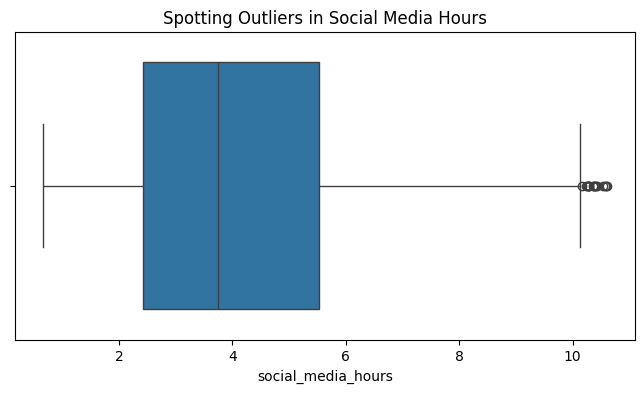

In [74]:
import seaborn as sns
import matplotlib.pyplot as plt

# Draw a boxplot for a specific column
plt.figure(figsize=(8, 4))
sns.boxplot(x=X_train_df['social_media_hours'])
plt.title('Spotting Outliers in Social Media Hours')
plt.show()

In [76]:
Q1 = X_train_df['social_media_hours'].quantile(0.25)
Q3 = X_train_df['social_media_hours'].quantile(0.75)
IQR = Q3 - Q1

In [81]:
upper_fence = Q3 + (1.5 * IQR)

In [83]:
print(f"The mathematical Upper Fence is: {upper_fence:.2f} hours")

The mathematical Upper Fence is: 10.17 hours


In [84]:
X_train_df['social_media_hours'] = np.where(
    X_train_df['social_media_hours'] > upper_fence,
    upper_fence,
    X_train_df['social_media_hours']
)

<Axes: xlabel='social_media_hours'>

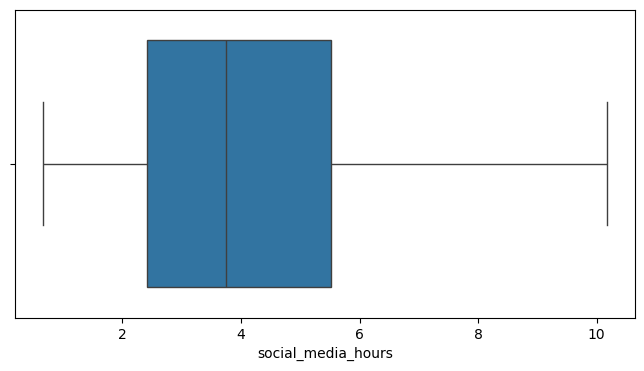

In [85]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=X_train_df['social_media_hours'])

In [86]:
from sklearn.preprocessing import StandardScaler

In [87]:
scaller = StandardScaler()

In [92]:
X_train_scalled = scaller.fit_transform(X_train_df)

In [97]:
X_test_scalled = scaller.transform(X_test_df)

In [100]:
X_test_scalled_df = pd.DataFrame(X_test_scalled, columns=X_test_df.columns)

In [101]:
X_test_scalled_df

,age,daily_screen_time,social_media_hours,study_hours,sleep_hours,notifications_per_day,focus_score,addiction_level
0,-0.440093,-1.010342,-1.280043,0.195097,-0.163368,0.774679,0.483098,-1.726405
1,1.093596,1.520772,-0.095564,-1.537395,0.005524,-0.934704,0.182409,-0.232490
2,-1.694930,-0.534436,-0.930295,0.291346,1.004801,-1.171772,0.483098,-0.232490
3,-0.161241,1.654730,2.711745,-0.837399,-0.254851,0.238157,-2.729246,1.261424
4,-0.997798,0.071903,0.249521,1.398216,-1.352648,0.038521,0.483098,-0.232490
...,...,...,...,...,...,...,...,...
1195,1.093596,-0.340549,0.519992,1.651965,0.104044,-0.560387,0.483098,1.261424
1196,-0.997798,-0.502709,-0.044267,-1.423646,-0.205591,1.336155,-1.344169,-0.232490
1197,-0.718946,-1.422794,-1.471238,0.081347,-0.430780,-1.246636,0.483098,-1.726405
1198,1.511875,1.023715,-0.403342,-0.531150,-1.064124,1.148996,-1.515603,-0.232490
